In [6]:
import pandas as pd

# Load the dataset
dataset_path = "Smart home all dataset.csv"
df = pd.read_csv(dataset_path)

# Display first few rows of the dataset
df.head()

,Timestamp,Action feature,Action result,Action result/num,Date,Time
0,2023-07-01T00:00:00,Back door,OFF,0,07/01/2023,00:00:00
1,2023-07-01T00:00:28,Hall,ON,100,07/01/2023,00:00:28
2,2023-07-01T00:00:56,Master Bedroom,OFF,0,07/01/2023,00:00:56
3,2023-07-01T00:01:24,Hall,ON,100,07/01/2023,00:01:24
4,2023-07-01T00:01:52,Landing,ON,100,07/01/2023,00:01:52


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73630 entries, 0 to 73629
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Timestamp          73630 non-null  object
 1   Action feature     73630 non-null  object
 2   Action result      73630 non-null  object
 3   Action result/num  73630 non-null  int64 
 4   Date               73630 non-null  object
 5   Time               73630 non-null  object
dtypes: int64(1), object(5)
memory usage: 3.4+ MB


In [3]:
df.describe(include='all', datetime_is_numeric=True)

,Timestamp,Action feature,Action result,Action result/num,Date,Time
count,73630,73630,73630,73630.000000,73630,73630
unique,73630,14,2,NaN,24,21600
top,2023-07-01T00:00:00,Master Bedroom,ON,NaN,07/01/2023,00:00:00
freq,1,12425,58727,NaN,3086,4
mean,NaN,NaN,NaN,79.759609,NaN,NaN
std,NaN,NaN,NaN,40.179443,NaN,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,100.000000,NaN,NaN
50%,NaN,NaN,NaN,100.000000,NaN,NaN
75%,NaN,NaN,NaN,100.000000,NaN,NaN


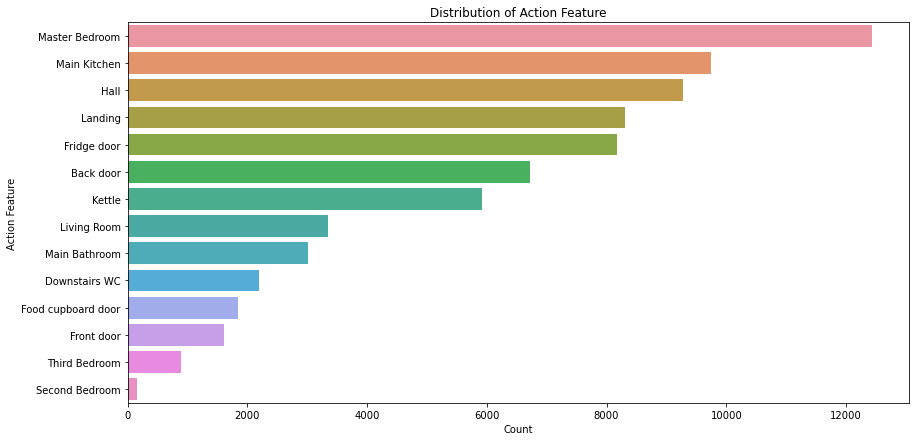

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14, 7))
sns.countplot(y='Action feature', data=df, order=df['Action feature'].value_counts().index)
plt.title('Distribution of Action Feature')
plt.xlabel('Count')
plt.ylabel('Action Feature')
plt.show()

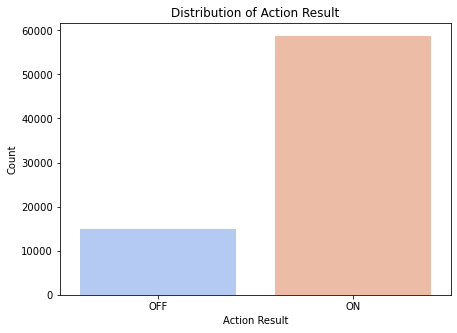

In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Action result', data=df, palette='coolwarm')
plt.title('Distribution of Action Result')
plt.xlabel('Action Result')
plt.ylabel('Count')
plt.show()

In [ ]:
plt.figure(figsize=(14, 7))

# Line plot of 'Action result/num' over time
sns.lineplot(x='Timestamp', y='Action result/num', data=df, ci=None)

# Set the title and labels of the plot
plt.title('Trend of Action Result/Num Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Action Result/Num')
plt.show()

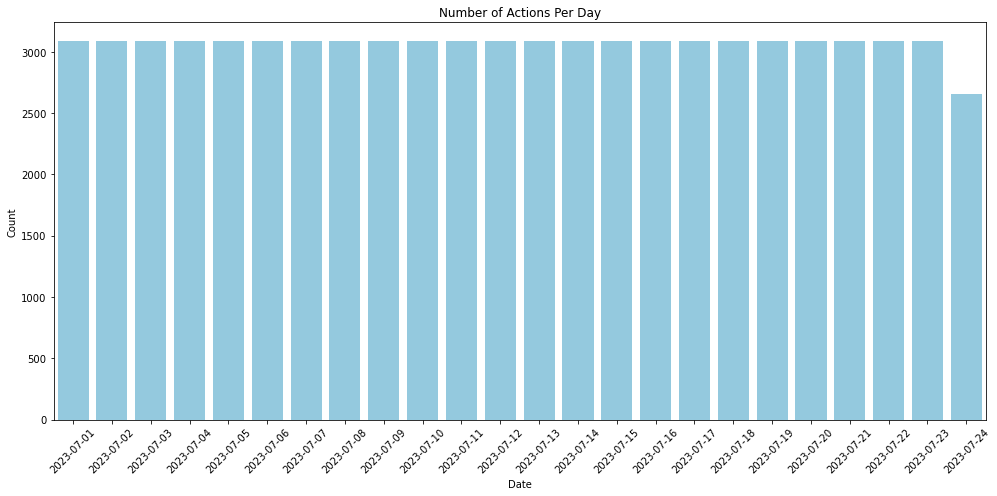

In [6]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
# Extract the date from the 'Timestamp' and create a new column 'Date_'
df['Date_'] = df['Timestamp'].dt.date

# Group the dataset by 'Date_' and count the number of actions per day
actions_per_day = df.groupby('Date_').size().reset_index(name='Count')

# Set the figure size
plt.figure(figsize=(14, 7))

# Bar plot of the number of actions per day
sns.barplot(x='Date_', y='Count', data=actions_per_day, color='skyblue')

# Set the title and labels of the plot
plt.title('Number of Actions Per Day')
plt.xlabel('Date')
plt.ylabel('Count')

# Rotate x labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

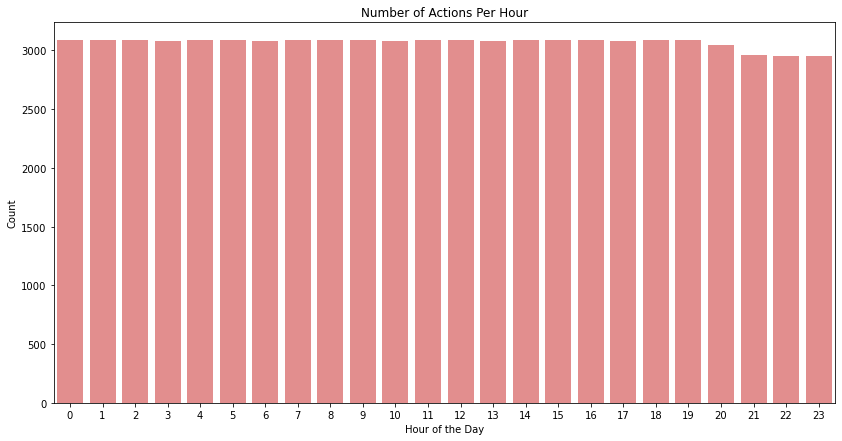

In [7]:
# Extract the hour from the 'Timestamp' and create a new column 'Hour'
df['Hour'] = df['Timestamp'].dt.hour

# Group the dataset by 'Hour' and count the number of actions per hour
actions_per_hour = df.groupby('Hour').size().reset_index(name='Count')

# Set the figure size
plt.figure(figsize=(14, 7))

# Bar plot of the number of actions per hour
sns.barplot(x='Hour', y='Count', data=actions_per_hour, color='lightcoral')

# Set the title and labels of the plot
plt.title('Number of Actions Per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Count')

plt.show()

# HMM Model

In [8]:
from sklearn.preprocessing import LabelEncoder

# Sort the dataset by timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.sort_values(by='Timestamp', inplace=True)

# Encode 'Action feature' and 'Action result' into numerical values
action_feature_encoder = LabelEncoder()
action_result_encoder = LabelEncoder()

df['Action_feature_encoded'] = action_feature_encoder.fit_transform(df['Action feature'])
df['Action_result_encoded'] = action_result_encoder.fit_transform(df['Action result'])

# Display the first few rows of the processed dataset
df.head()

,Timestamp,Action feature,Action result,Action result/num,Date,Time,Date_,Hour,Action_feature_encoded,Action_result_encoded
0,2023-07-01 00:00:00,Back door,OFF,0,07/01/2023,00:00:00,2023-07-01,0,0,0
1,2023-07-01 00:00:28,Hall,ON,100,07/01/2023,00:00:28,2023-07-01,0,5,1
2,2023-07-01 00:00:56,Master Bedroom,OFF,0,07/01/2023,00:00:56,2023-07-01,0,11,0
3,2023-07-01 00:01:24,Hall,ON,100,07/01/2023,00:01:24,2023-07-01,0,5,1
4,2023-07-01 00:01:52,Landing,ON,100,07/01/2023,00:01:52,2023-07-01,0,7,1


In [9]:
from hmmlearn import hmm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
# Prepare the sequence data
# Combining both 'Action_feature_encoded' and 'Action_result_encoded' for the HMM
sequence_data = df[['Action_feature_encoded', 'Action_result_encoded']].values

# Reshape the data to meet the requirements of hmmlearn
sequence_data = sequence_data.reshape(-1, 1)

# Number of hidden states ('ON' and 'OFF')
n_hidden_states = 2

# Split data into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, shuffle=False)


In [10]:
# Feature Engineering on training set
train_df['Combined_feature'] = train_df['Action_feature_encoded'].astype(str) + train_df['Action_result_encoded'].astype(str)
combined_feature_encoder = LabelEncoder()
train_df['Combined_feature_encoded'] = combined_feature_encoder.fit_transform(train_df['Combined_feature'])

# 4. Train the HMM
sequence_data = train_df['Combined_feature_encoded'].values.reshape(-1, 1)
hmm_model = hmm.MultinomialHMM(n_components=2, n_iter=100)
hmm_model.fit(sequence_data)

MultinomialHMM(n_components=2, n_iter=100,
               random_state=RandomState(MT19937) at 0x2BCEDE9F340)

In [11]:
# Extract the model parameters
initial_state_prob = np.exp(hmm_model.startprob_)
transition_matrix = np.exp(hmm_model.transmat_)
emission_matrix = np.exp(hmm_model.emissionprob_)

print("Initial State Probabilities:", initial_state_prob)
print("Transition Matrix:", transition_matrix)
print("Emission Matrix:", emission_matrix)

Initial State Probabilities: [1.00000149 2.71827779]
Transition Matrix: [[1.6566751  1.64080563]
 [1.65527512 1.64219337]]
Emission Matrix: [[1.00309611 1.07681613 1.15943034 1.03899236 1.0518109  1.12281317
  1.00144837 1.01000152 1.01305676 1.01494988 1.05370598 1.07652072
  1.0040988  1.01127613 1.15502761 1.04242674 1.00817155 1.11460464
  1.02664545 1.06310833]
 [1.09307753 1.01564434 1.12432462 1.02148349 1.02666434 1.15182415
  1.00270971 1.01387673 1.01197752 1.01012576 1.05773914 1.03912169
  1.01760462 1.01139765 1.11389915 1.03955472 1.07768774 1.12561354
  1.06910287 1.02121335]]


In [12]:
#Normalize Initial state probabilities
sum_initial_state_probabilities = sum(initial_state_prob)
normalized_initial_state_probabilities = [prob / sum_initial_state_probabilities for prob in initial_state_prob]

# Normalize Transition Matrix
normalized_transition_matrix = []
for row in transition_matrix:
    row_sum = sum(row)
    normalized_row = [value / row_sum for value in row]
    normalized_transition_matrix.append(normalized_row)


# Normalize Emission Matrix
normalized_emission_matrix = []
for row in emission_matrix:
    row_sum = sum(row)
    normalized_row = [value / row_sum for value in row]
    normalized_emission_matrix.append(normalized_row)

print("Normalized Initial State Probabilities:", normalized_initial_state_probabilities)
print("Normalized Transition Matrix:", normalized_transition_matrix)
print("Normalized Emission Matrix:", normalized_emission_matrix)

Normalized Initial State Probabilities: [0.2689420060824844, 0.7310579939175156]
Normalized Transition Matrix: [[0.5024063011221774, 0.4975936988778227], [0.5019836037784592, 0.49801639622154076]]
Normalized Emission Matrix: [[0.0476575465090907, 0.051160017974294474, 0.05508505577770773, 0.04936299366991352, 0.0499720078798138, 0.0533453579916161, 0.04757926179360372, 0.04798562560898637, 0.048130781387112985, 0.048220724701033946, 0.0500620439881509, 0.051145982516439495, 0.0477051846328657, 0.048046182956479506, 0.05487588030843153, 0.049526162250418865, 0.047898682773328975, 0.05295536701886993, 0.04877638640248136, 0.05050875385936055], [0.051940892727869094, 0.04826142012661552, 0.05342569298392589, 0.048538885182225155, 0.048785068950230825, 0.054732416703988936, 0.04764679210008386, 0.04817742679524353, 0.048087179827073945, 0.04799918813936746, 0.05026168220655034, 0.04937701765449188, 0.048354568614821306, 0.04805962567743823, 0.05293029532507579, 0.049397594211590456, 0.0512

In [13]:
# Set the normalized initial state probabilities
hmm_model.startprob_ = normalized_initial_state_probabilities

# Set the normalized transition matrix
hmm_model.transmat_ = normalized_transition_matrix

# Set the normalized emission matrix
hmm_model.emissionprob_ = normalized_emission_matrix

In [14]:
import datetime
LENGTH_OF_SEQUENCE = 14726
generated_sequence, _ = hmm_model.sample(LENGTH_OF_SEQUENCE)

# Decode Sequence
decoded_combined_features = combined_feature_encoder.inverse_transform(generated_sequence.ravel())
decoded_actions = [int(str(x)[:-1]) for x in decoded_combined_features]
decoded_results = [int(str(x)[-1]) for x in decoded_combined_features]

# Translate back to original labels
decoded_actions_labels = action_feature_encoder.inverse_transform(decoded_actions)
decoded_results_labels = action_result_encoder.inverse_transform(decoded_results)

# Generate timestamps
# Starting timestamp 
start_time = datetime.datetime(2023, 11, 1, 7, 0, 0)

# Fixed interval of 5 minutes between each action
time_interval = datetime.timedelta(minutes=5)

# Generate the list of timestamps
timestamps = [start_time + i*time_interval for i in range(LENGTH_OF_SEQUENCE)]

# a DataFrame for the generated sequence
generated_df = pd.DataFrame({
    'Timestamp': timestamps,
    'Generated_Action': decoded_actions_labels,
    'Generated_Result': decoded_results_labels
})

print(generated_df)

                Timestamp    Generated_Action Generated_Result
0     2023-11-01 07:00:00              Kettle               ON
1     2023-11-01 07:05:00  Food cupboard door              OFF
2     2023-11-01 07:10:00         Living Room               ON
3     2023-11-01 07:15:00  Food cupboard door              OFF
4     2023-11-01 07:20:00  Food cupboard door              OFF
...                   ...                 ...              ...
14721 2023-12-22 09:45:00         Fridge door              OFF
14722 2023-12-22 09:50:00         Fridge door              OFF
14723 2023-12-22 09:55:00       Downstairs WC               ON
14724 2023-12-22 10:00:00             Landing               ON
14725 2023-12-22 10:05:00  Food cupboard door               ON

[14726 rows x 3 columns]


In [15]:
# Feature engineering on test set
test_df['Combined_feature'] = test_df['Action_feature_encoded'].astype(str) + test_df['Action_result_encoded'].astype(str)
test_df['Combined_feature_encoded'] = combined_feature_encoder.transform(test_df['Combined_feature'])
test_sequence = test_df['Combined_feature_encoded'].values.reshape(-1, 1)
log_likelihood = hmm_model.score(test_sequence)
print(f"Log-likelihood on test data: {log_likelihood}")

Log-likelihood on test data: -43636.58041753557


In [16]:
train_log_likelihood = hmm_model.score(sequence_data)  # sequence_data is your training data
print(f"Log-likelihood on training data: {train_log_likelihood}")

Log-likelihood on training data: -174546.75755583213


In [17]:
#Comparison of State Distributions
# Generate states from the model based on the test sequence length
_, test_states = hmm_model.sample(len(test_df))


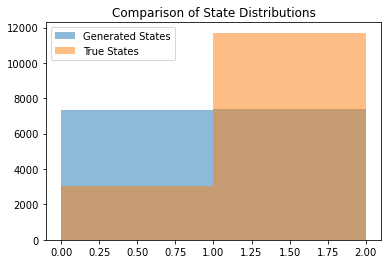

In [18]:
# Plotting
import matplotlib.pyplot as plt
plt.figure()
plt.hist(test_states, bins=range(3), alpha=0.5, label='Generated States')
plt.hist(test_df['Action_result_encoded'], bins=range(3), alpha=0.5, label='True States')
plt.title('Comparison of State Distributions')
plt.legend()
plt.show()

In [19]:
#Comparison of Action Distributions
# Extract generated actions from the generated sequence
generated_actions = [int(str(x)[:-1]) for x in combined_feature_encoder.inverse_transform(generated_sequence.ravel())]

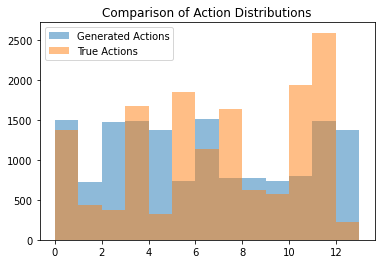

In [20]:
# Plotting
plt.figure()
plt.hist(generated_actions, bins=np.arange(min(test_df['Action_feature_encoded']), max(test_df['Action_feature_encoded']) + 1), alpha=0.5, label='Generated Actions')
plt.hist(test_df['Action_feature_encoded'], bins=np.arange(min(test_df['Action_feature_encoded']), max(test_df['Action_feature_encoded']) + 1), alpha=0.5, label='True Actions')
plt.title('Comparison of Action Distributions')
plt.legend()
plt.show()


In [22]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(test_df['Action_result_encoded'], decoded_results)

accuracy = accuracy_score(test_df['Action_result_encoded'], decoded_results)
classification_rep_hmm = classification_report(test_df['Action_result_encoded'], decoded_results)

print("Accuracy:", accuracy)
print("Classification Report:\n", classification_rep_hmm)

Accuracy: 0.619788129838381
Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.30      0.24      3020
           1       0.80      0.70      0.75     11706

    accuracy                           0.62     14726
   macro avg       0.50      0.50      0.49     14726
weighted avg       0.67      0.62      0.64     14726



# Naive Bayes Classifier

In [23]:
# Importing LabelEncoder from scikit-learn
from sklearn.preprocessing import LabelEncoder

# label encoding on 'Action feature' and 'Action result'
label_encoder_feature = LabelEncoder()
label_encoder_result = LabelEncoder()
df['Action_feature_encoded'] = label_encoder_feature.fit_transform(df['Action feature'])
df['Action_result_encoded'] = label_encoder_result.fit_transform(df['Action result'])

# Spliting the data into training and testing sets (80% training, 20% testing)
X = df[['Action_feature_encoded']]
y = df['Action_result_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the first few rows of the training and testing sets
X_train.head(), y_train.head(), X_test.head(), y_test.head()

(       Action_feature_encoded
 39559                       8
 66748                       8
 52070                       7
 58311                       6
 522                        11,
 39559    1
 66748    1
 52070    1
 58311    1
 522      1
 Name: Action_result_encoded, dtype: int32,
        Action_feature_encoded
 17457                       5
 50194                      10
 3725                       10
 56437                      13
 2990                        6,
 17457    1
 50194    1
 3725     1
 56437    1
 2990     1
 Name: Action_result_encoded, dtype: int32)

In [24]:
from sklearn.naive_bayes import GaussianNB
# Importing accuracy_score and classification_report from scikit-learn
from sklearn.metrics import accuracy_score, classification_report

# Initialize the classifier
gnb = GaussianNB()

# Training the classifier
gnb.fit(X_train, y_train)

# Making predictions on the test set
y_pred = gnb.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)



E:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [25]:
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [26]:
accuracy

0.7973652044003803

In [27]:
print("Classification Report:\n", classification_rep)

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      2984
           1       0.80      1.00      0.89     11742

    accuracy                           0.80     14726
   macro avg       0.40      0.50      0.44     14726
weighted avg       0.64      0.80      0.71     14726



In [28]:
from sklearn.utils import resample

# Combining the training data back together
train_data = pd.concat([X_train, y_train], axis=1)

# Separating the classes
on_data = train_data[train_data['Action_result_encoded'] == 1]
off_data = train_data[train_data['Action_result_encoded'] == 0]

# Performing oversampling on the 'OFF' class
off_data_upsampled = resample(off_data, 
                              replace=True,                   
                              n_samples=len(on_data),         
                              random_state=42)                 

# Combining the upsampled minority class with the original majority class
train_data_upsampled = pd.concat([on_data, off_data_upsampled])

# Check the new class distribution
new_class_distribution = train_data_upsampled['Action_result_encoded'].value_counts(normalize=True)

# Preparing the new training data
X_train_upsampled = train_data_upsampled[['Action_feature_encoded']]
y_train_upsampled = train_data_upsampled['Action_result_encoded']

new_class_distribution


1    0.5
0    0.5
Name: Action_result_encoded, dtype: float64

In [29]:
# Training the Naive Bayes Classifier on the upsampled training data
gnb_upsampled = GaussianNB()
gnb_upsampled.fit(X_train_upsampled, y_train_upsampled)

# Making predictions on the test set
y_pred_upsampled = gnb_upsampled.predict(X_test)

# Evaluate the model
accuracy_upsampled = accuracy_score(y_test, y_pred_upsampled)
classification_rep_upsampled = classification_report(y_test, y_pred_upsampled)


In [30]:
y_pred_upsampled

array([0, 1, 1, ..., 1, 0, 1])

In [31]:
# Creating DataFrame to show predictions along with actions
y_pred_upsampled_with_action = pd.DataFrame({'Action_feature_encoded': X_test['Action_feature_encoded'].values, 
                                            'Predicted_Result_encoded': y_pred_upsampled})

# Decode the 'Predicted_Result_encoded' and 'Action_feature_encoded' back to original labels
y_pred_upsampled_with_action['Predicted_Result'] = label_encoder_result.inverse_transform(y_pred_upsampled_with_action['Predicted_Result_encoded'])
y_pred_upsampled_with_action['Action_feature'] = label_encoder_feature.inverse_transform(y_pred_upsampled_with_action['Action_feature_encoded'])

# Droping the encoded columns for better readability
y_pred_upsampled_with_action.drop(['Predicted_Result_encoded', 'Action_feature_encoded'], axis=1, inplace=True)

In [32]:
y_pred_upsampled_with_action

,Predicted_Result,Action_feature
0,OFF,Hall
1,ON,Main Kitchen
2,ON,Main Kitchen
3,ON,Third Bedroom
4,ON,Kettle
...,...,...
14721,ON,Master Bedroom
14722,ON,Kettle
14723,ON,Master Bedroom
14724,OFF,Fridge door


In [33]:
accuracy_upsampled

0.6384625831862013

In [34]:
print("Classification Report:\n", classification_rep_upsampled)

Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.61      0.41      2984
           1       0.87      0.64      0.74     11742

    accuracy                           0.64     14726
   macro avg       0.59      0.63      0.57     14726
weighted avg       0.75      0.64      0.67     14726



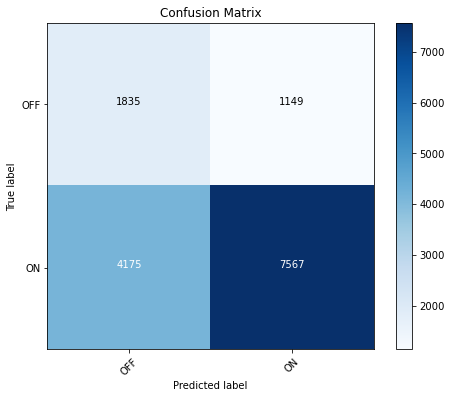

In [35]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = range(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, str(cm[i][j]), horizontalalignment="center", color="white" if cm[i][j] > cm.max() / 2 else "black")
plt.show()
plot_confusion_matrix(y_test, y_pred_upsampled, labels=['OFF', 'ON'])

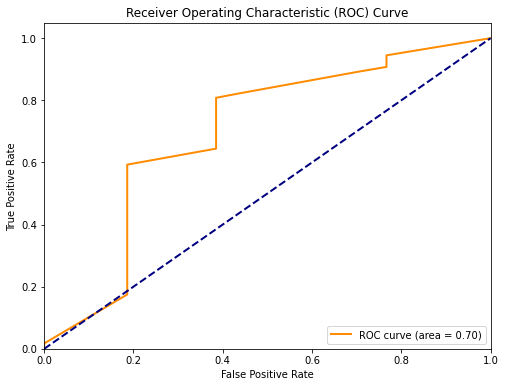

In [36]:
def plot_roc_curve(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()
plot_roc_curve(y_test, gnb_upsampled.predict_proba(X_test)[:, 1])

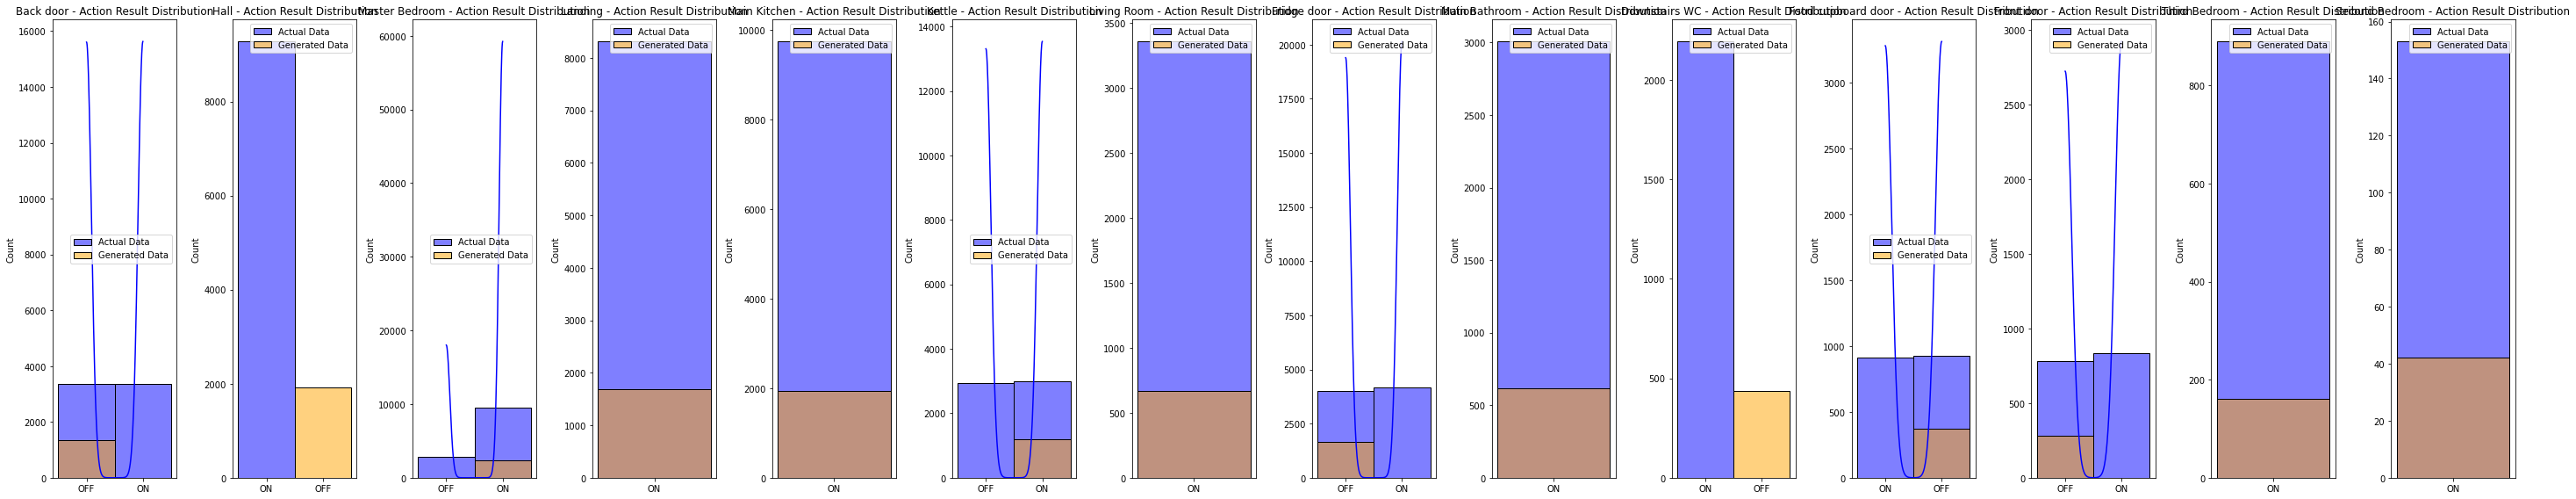

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

action_features = df['Action feature'].unique()

# Creating subplots for each 'Action feature'
num_features = len(action_features)
fig, axes = plt.subplots(nrows=1, ncols=num_features, figsize=(40, 8))

zoom_in_x = (0, 5)  # Example: Zoom in on x-axis from 0 to 5
zoom_in_y = (0, 500)  # Example: Zoom in on y-axis from 0 to 500

# Ploting histograms or density plots for 'Action result' for each 'Action feature'
for i, action_feature in enumerate(action_features):
    # Filter data for the current 'Action feature'
    actual_data = df[df['Action feature'] == action_feature]['Action result']
    generated_data = y_pred_upsampled_with_action[y_pred_upsampled_with_action['Action_feature'] == action_feature]['Predicted_Result']

    
    sns.histplot(actual_data, kde=True, ax=axes[i], label='Actual Data', color='blue')
    sns.histplot(generated_data, kde=True, ax=axes[i], label='Generated Data', color='orange')
    axes[i].set_title(f'{action_feature} - Action Result Distribution')
    axes[i].set_xlabel('')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Decesion Tree

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

label_encoder_feature = LabelEncoder()
label_encoder_result = LabelEncoder()

df['Action_feature_encoded'] = label_encoder_feature.fit_transform(df['Action feature'])
df['Action_result_encoded'] = label_encoder_result.fit_transform(df['Action result'])

# Spliting the data into features (X) and target variable (y)
X = df[['Action_feature_encoded']]  
y = df['Action_result_encoded']  

# Spliting the data into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating a Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)  

# Training the model on the training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [39]:
# Making predictions on the test data
y_pred = clf.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [40]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Printing evaluation results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_rep)

Accuracy: 0.80
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.06      0.11      2984
           1       0.81      0.98      0.89     11742

    accuracy                           0.80     14726
   macro avg       0.66      0.52      0.50     14726
weighted avg       0.75      0.80      0.73     14726



In [41]:
# checking training accuracy for overfitting data
y_train_pred = clf.predict(X_train)
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_train

0.7976707863642537

In [42]:
import pandas as pd

# Creating a DataFrame with the predicted labels
predictions_df = pd.DataFrame({'Action_feature_encoded': X_test['Action_feature_encoded'].values, 
                                            'Predicted_Result_encoded': y_pred})

# Inverse transform the predicted labels back to original 'Action result' labels
predictions_df['Predicted_Result'] = label_encoder_result.inverse_transform(predictions_df['Predicted_Result_encoded'])

# Adding the 'Action feature' column from the original DataFrame 'df'
predictions_df['Action feature'] = label_encoder_feature.inverse_transform(predictions_df['Action_feature_encoded'])

# Droping the encoded columns for better readability
predictions_df.drop(['Predicted_Result_encoded'], axis=1, inplace=True)
predictions_df.drop(['Action_feature_encoded'], axis=1, inplace=True)

# Display the DataFrame
print(predictions_df)

      Predicted_Result  Action feature
0                   ON            Hall
1                   ON    Main Kitchen
2                   ON    Main Kitchen
3                   ON   Third Bedroom
4                   ON          Kettle
...                ...             ...
14721               ON  Master Bedroom
14722               ON          Kettle
14723               ON  Master Bedroom
14724               ON     Fridge door
14725               ON         Landing

[14726 rows x 2 columns]


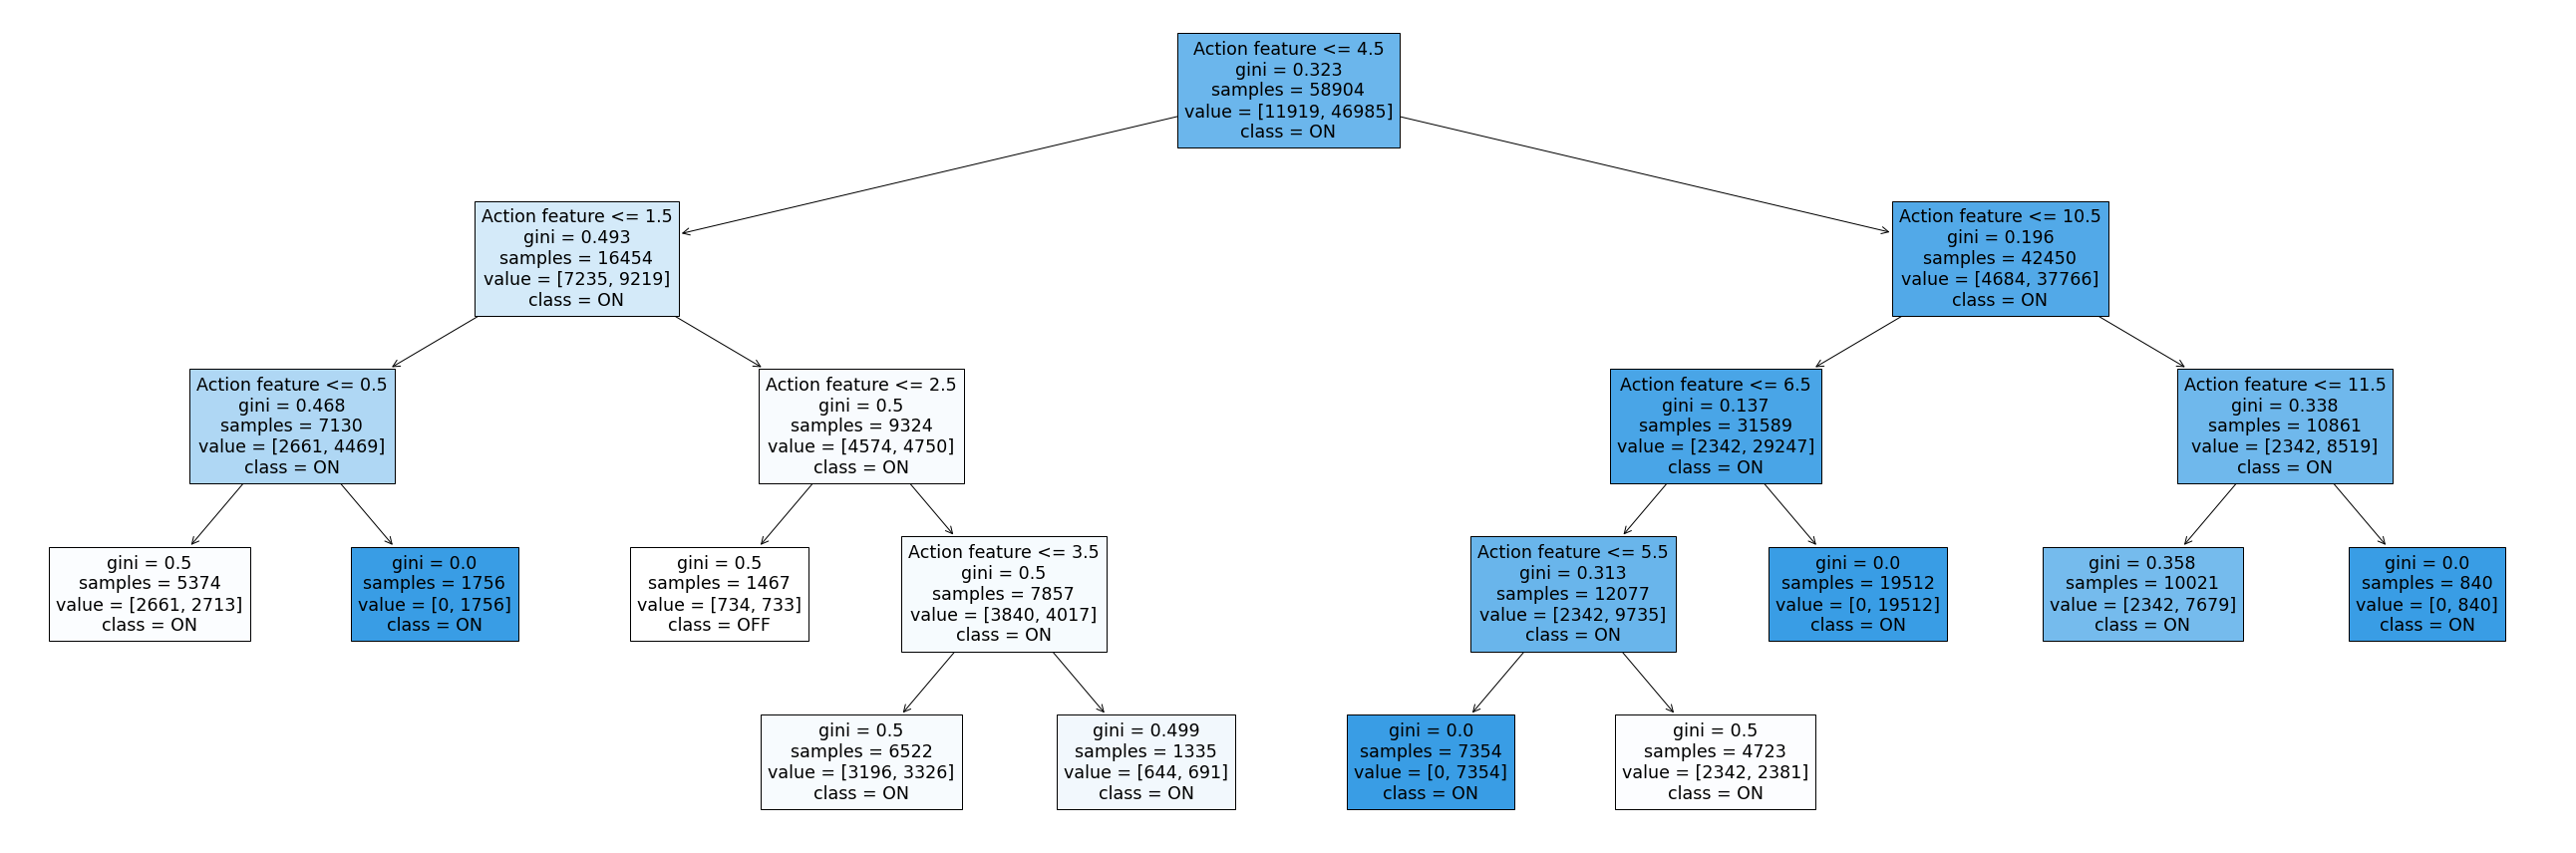

In [43]:
# Visualizing the Decision Tree
import matplotlib.pyplot as plt
plt.figure(figsize=(36, 12))
zoom_in_x = (0, 5)  # Example: Zoom in on x-axis from 0 to 5
zoom_in_y = (0, 500)  # Example: Zoom in on y-axis from 0 to 500
plot_tree(clf, filled=True, feature_names=['Action feature'], class_names=label_encoder_result.classes_)
plt.tight_layout()
plt.show()

E:\anaconda\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)
E:\anaconda\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


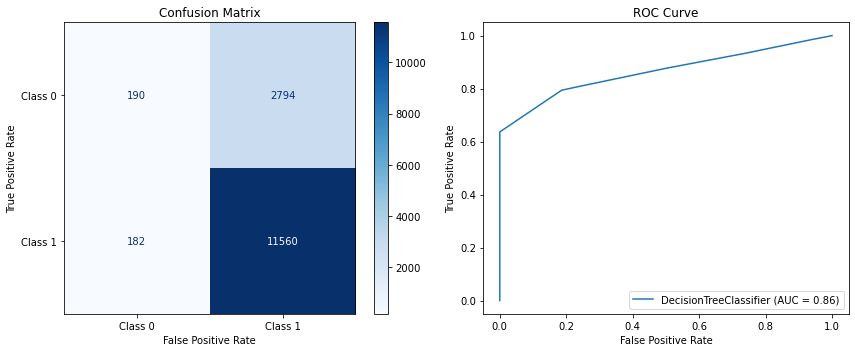

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, plot_confusion_matrix, plot_roc_curve

# Creating a figure with subplots for the confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calculating the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Ploting the confusion matrix
plot_confusion_matrix(clf, X_test, y_test, ax=axes[0], cmap=plt.cm.Blues, display_labels=['Class 0', 'Class 1'])
axes[0].set_title('Confusion Matrix')

# Ploting the ROC curve
roc_display = plot_roc_curve(clf, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')

# Set the axis labels
for ax in axes:
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

plt.tight_layout()
plt.show()



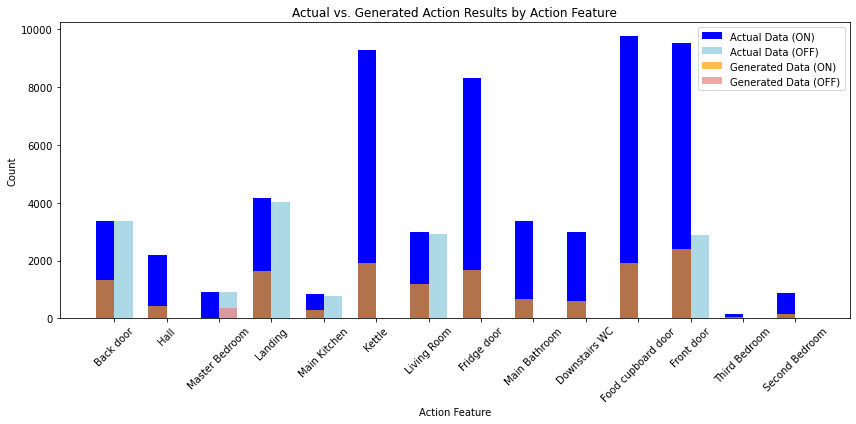

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Grouping the actual data (df) by 'Action feature' and 'Action result' and count occurrences
actual_grouped = df.groupby(['Action feature', 'Action result']).size().unstack(fill_value=0)

# Grouping the generated data (predictions_df) by 'Action feature' and 'Predicted_Result' and count occurrences
generated_grouped = predictions_df.groupby(['Action feature', 'Predicted_Result']).size().unstack(fill_value=0)

# Taking unique 'Action feature' values
action_features = df['Action feature'].unique()
bar_width = 0.35

# Creating an array of indices for the x-axis ticks
x = np.arange(len(action_features))

# Creating subplots for each 'Action feature'
fig, ax = plt.subplots(figsize=(12, 6))

# Ploting the actual data
actual_bars = ax.bar(x - bar_width/2, actual_grouped['ON'], bar_width, label='Actual Data (ON)', color='blue')
actual_bars = ax.bar(x + bar_width/2, actual_grouped['OFF'], bar_width, label='Actual Data (OFF)', color='lightblue')

# Ploting the generated data
generated_bars = ax.bar(x - bar_width/2, generated_grouped['ON'], bar_width, label='Generated Data (ON)', color='orange', alpha=0.7)
generated_bars = ax.bar(x + bar_width/2, generated_grouped['OFF'], bar_width, label='Generated Data (OFF)', color='lightcoral', alpha=0.7)

# Customizing the plot
ax.set_xlabel('Action Feature')
ax.set_ylabel('Count')
ax.set_title('Actual vs. Generated Action Results by Action Feature')
ax.set_xticks(x)
ax.set_xticklabels(action_features)
ax.legend()

# Display the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
